# Phase 3 — Embeddings Comparison
Run after `python scripts/run_phase3.py`.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path
from sklearn.decomposition import PCA
from src.embeddings.tfidf import TFIDFEmbedder
from src.embeddings.word2vec import Word2VecEmbedder
from src.embeddings.distilbert import DistilBERTEmbedder

In [2]:
SAMPLE_TEXTS = [
    'absolutely terrible broke immediately waste money',
    'not satisfied multiple issues disappointed return',
    'okay nothing special average mediocre',
    'good product works well satisfied recommend',
    'amazing outstanding best purchase ever love incredible',
]
LABELS = [0, 1, 2, 3, 4]
COLORS = ['#d62728', '#ff7f0e', '#7f7f7f', '#2ca02c', '#1f77b4']

## TF-IDF

In [3]:
tfidf = TFIDFEmbedder(max_features=1000)
tfidf.fit(SAMPLE_TEXTS)
v_tfidf = tfidf.transform(SAMPLE_TEXTS)
print(f'TF-IDF shape: {v_tfidf.shape}  sparse={hasattr(v_tfidf, "toarray")}')

TF-IDF shape: (5, 54)  sparse=True


## Word2Vec

In [4]:
w2v = Word2VecEmbedder(vector_size=300, min_count=1)
w2v.fit(SAMPLE_TEXTS)
v_w2v = w2v.transform(SAMPLE_TEXTS)
print(f'Word2Vec shape: {v_w2v.shape}')

Word2Vec shape: (5, 300)


## DistilBERT

In [5]:
bert = DistilBERTEmbedder()
v_bert = bert.transform(SAMPLE_TEXTS)
print(f'DistilBERT shape: {v_bert.shape}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT shape: (5, 768)


## PCA visualisation (2D)

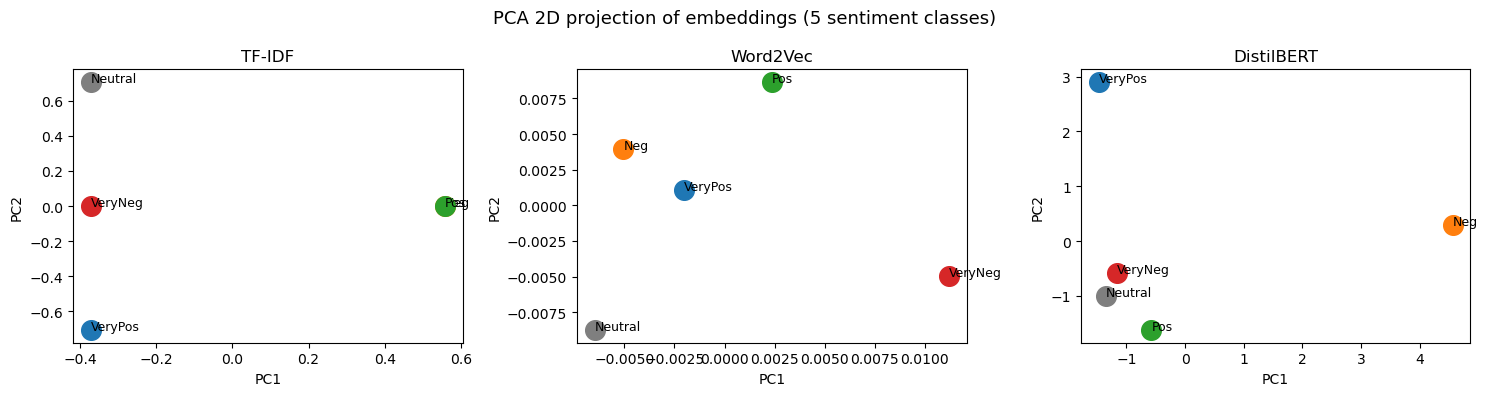

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
label_str = ['VeryNeg', 'Neg', 'Neutral', 'Pos', 'VeryPos']

for ax, (name, vec) in zip(axes, [
    ('TF-IDF', v_tfidf.toarray() if hasattr(v_tfidf, 'toarray') else v_tfidf),
    ('Word2Vec', v_w2v),
    ('DistilBERT', v_bert),
]):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(vec)
    for i, (x, y) in enumerate(coords):
        ax.scatter(x, y, color=COLORS[i], s=200, zorder=3)
        ax.annotate(label_str[i], (x, y), fontsize=9)
    ax.set_title(name)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('PCA 2D projection of embeddings (5 sentiment classes)', fontsize=13)
plt.tight_layout()
plt.show()

## Inference speed benchmark

In [7]:
N = 50
texts50 = SAMPLE_TEXTS * (N // len(SAMPLE_TEXTS) + 1)
texts50 = texts50[:N]

for name, emb in [('TF-IDF', tfidf), ('Word2Vec', w2v), ('DistilBERT', bert)]:
    t0 = time.perf_counter()
    emb.transform(texts50[:10] if name == 'DistilBERT' else texts50)
    n = 10 if name == 'DistilBERT' else N
    ms = (time.perf_counter() - t0) * 1000 / n
    print(f'{name:12s}: {ms:.2f} ms/sample')

TF-IDF      : 0.03 ms/sample
Word2Vec    : 0.05 ms/sample
DistilBERT  : 5.81 ms/sample
